In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].apply(lambda x: iris.target_names[x])

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df['target_name'].value_counts()

,count
target_name,
setosa,50
versicolor,50
virginica,50


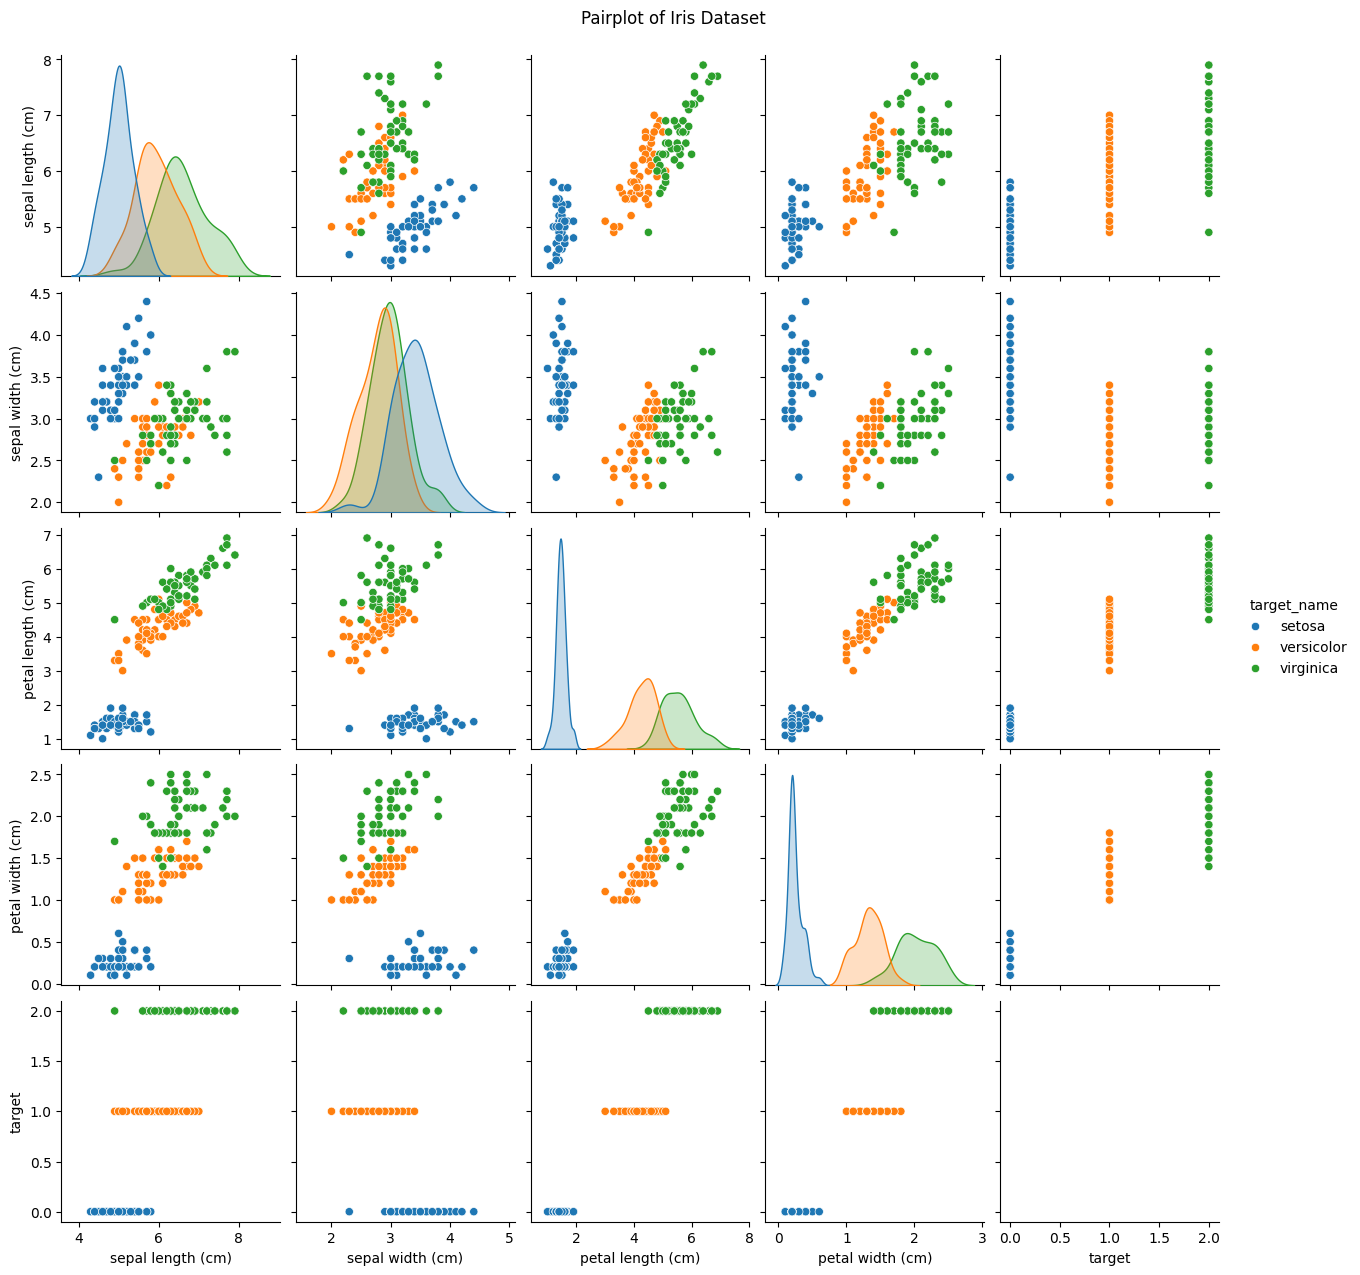

In [7]:
# Pairplot to visualize features
sns.pairplot(df, hue='target_name')
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

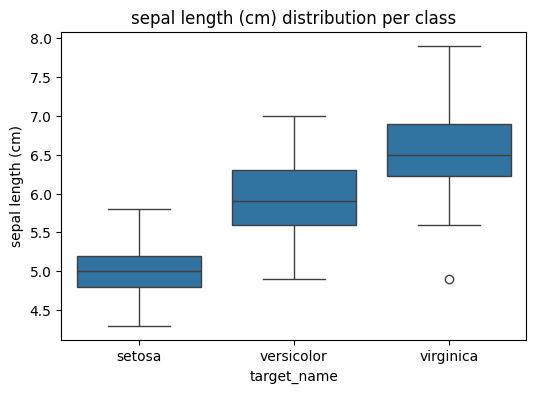

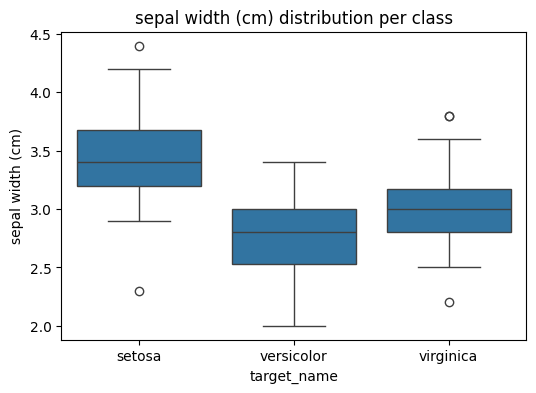

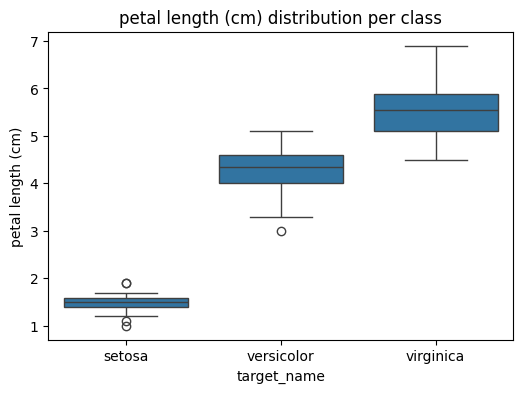

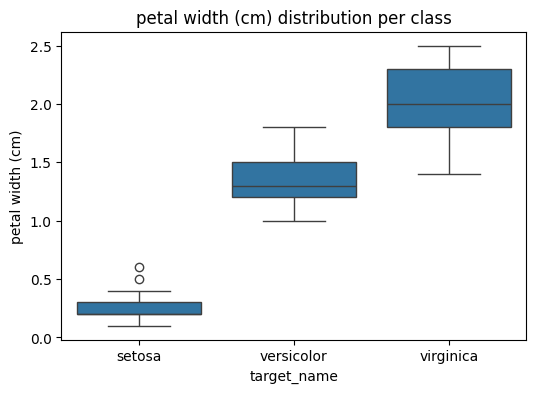

In [8]:
# Feature distributions
for column in iris.feature_names:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='target_name', y=column, data=df)
    plt.title(f'{column} distribution per class')
    plt.show()

In [13]:
X = df[iris.feature_names]
y = df['target']

In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [15]:
# feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)  # use long for CrossEntropyLoss
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [17]:
# Model Definition
class IrisModel(nn.Module):
    def __init__(self):
        super(IrisModel, self).__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 12)
        self.output = nn.Linear(12, 3)  # 3 classes

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.output(x)  # No softmax here
        return x

model = IrisModel()

In [18]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()  # expects raw logits
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# --- Training Loop ---
epochs = 500
losses = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 50/500, Loss: 0.1028
Epoch 100/500, Loss: 0.0304
Epoch 150/500, Loss: 0.0187
Epoch 200/500, Loss: 0.0094
Epoch 250/500, Loss: 0.0044
Epoch 300/500, Loss: 0.0023
Epoch 350/500, Loss: 0.0014
Epoch 400/500, Loss: 0.0009
Epoch 450/500, Loss: 0.0007
Epoch 500/500, Loss: 0.0005


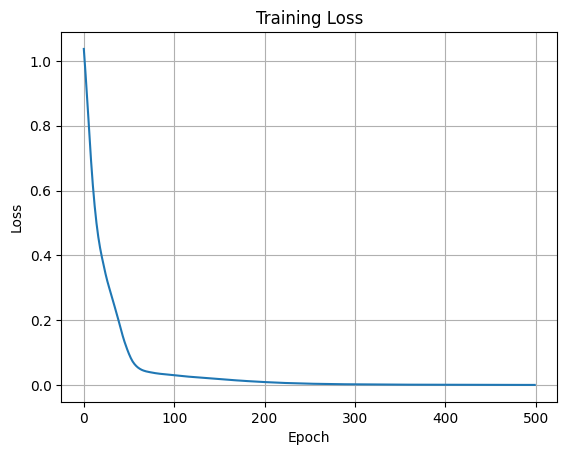

In [19]:
# Plot training loss
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



In [20]:
# --- Evaluation ---
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    y_pred = torch.argmax(y_pred_logits, dim=1)

# Accuracy
accuracy = accuracy_score(y_test_tensor, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_tensor, y_pred, target_names=iris.target_names))

Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [21]:
# --- Inference ---
sample = [[5.1, 3.5, 1.4, 0.2]]  # likely a setosa
sample_scaled = scaler.transform(sample)
sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output).item()
    print(f"Predicted class: {iris.target_names[predicted_class]}")

Predicted class: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
